# Heart Disease Risk Assessment Using Machine Learning Techniques (Decision Tree- C5.0)

# Problem Statement

Cardiovascular diseases are among the leading causes of death worldwide. Early identification of individuals at risk of heart disease can help healthcare professionals provide timely treatment and reduce mortality rates.

This project aims to develop a machine learning model that predicts the presence of heart disease based on patient health and clinical attributes such as age, gender, chest pain type, resting blood pressure, cholesterol level, fasting blood sugar, resting ECG results, maximum heart rate achieved, exercise-induced angina, ST depression (Oldpeak), and ST slope.

By analyzing these medical factors, the model seeks to accurately classify whether a patient is likely to have heart disease (HeartDisease = 1) or not (HeartDisease = 0). The developed solution can assist healthcare practitioners in making data-driven decisions and improving early diagnosis of cardiovascular conditions.

# Dataset Structure

- The dataset contains medical and clinical information of patients, including demographic details, cardiovascular measurements, ECG results, and exercise-related indicators. The goal is to analyze the factors associated with heart disease and build a predictive classification model.
- Total Rows           : 918
- Total Columns        : 12
- Independent Variables:
1. Age
2. Sex
3. ChestPainType
4. RestingBP
5. Cholesterol
6. FastingBS
7. RestingECG
8. MaxHR
9. ExerciseAngina
10. Oldpeak
11. ST_Slope
- Target Column        : HeartDisease
- Problem Type         : Classification Problem
- Model Used           : Decision Tre (C5.0)

# Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier   
from sklearn import tree
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style='darkgrid',palette='viridis')

# Dataset Loaded

In [3]:
df=pd.read_csv("heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# Data Understanding

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [6]:
print(f'Number of rows:{df.shape[0]}')
print(f'Number oF columns: {df.shape[1]}')

Number of rows:918
Number oF columns: 12


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.describe(include=object)

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [10]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

# Data Quality Check

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

# Exploratory Data Analysis

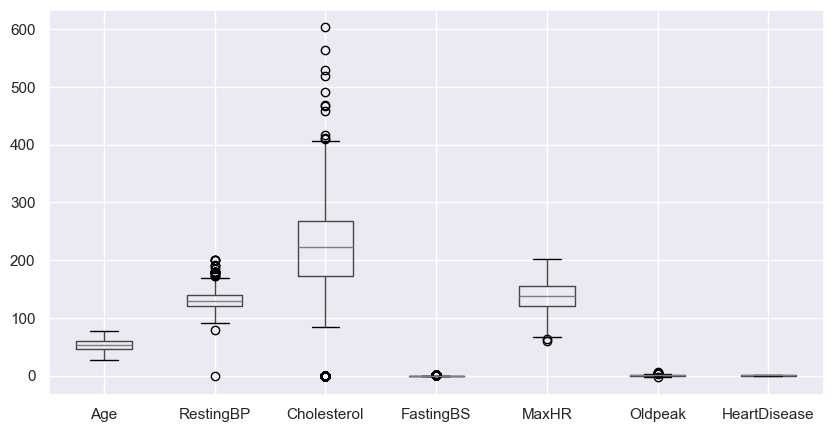

In [13]:
plt.figure(figsize=(10,5))
df.boxplot()
plt.show()

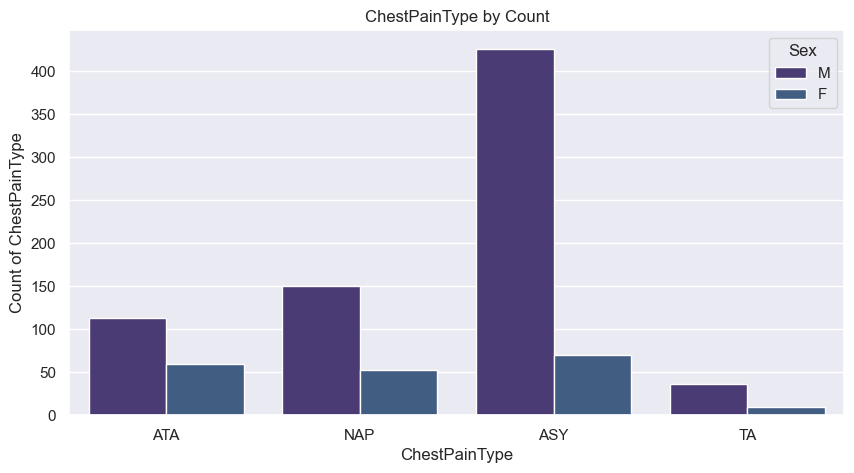

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['ChestPainType'],data=df,hue=df['Sex'])
plt.xlabel('ChestPainType')
plt.ylabel('Count of ChestPainType')
plt.title('ChestPainType by Count')
plt.show()

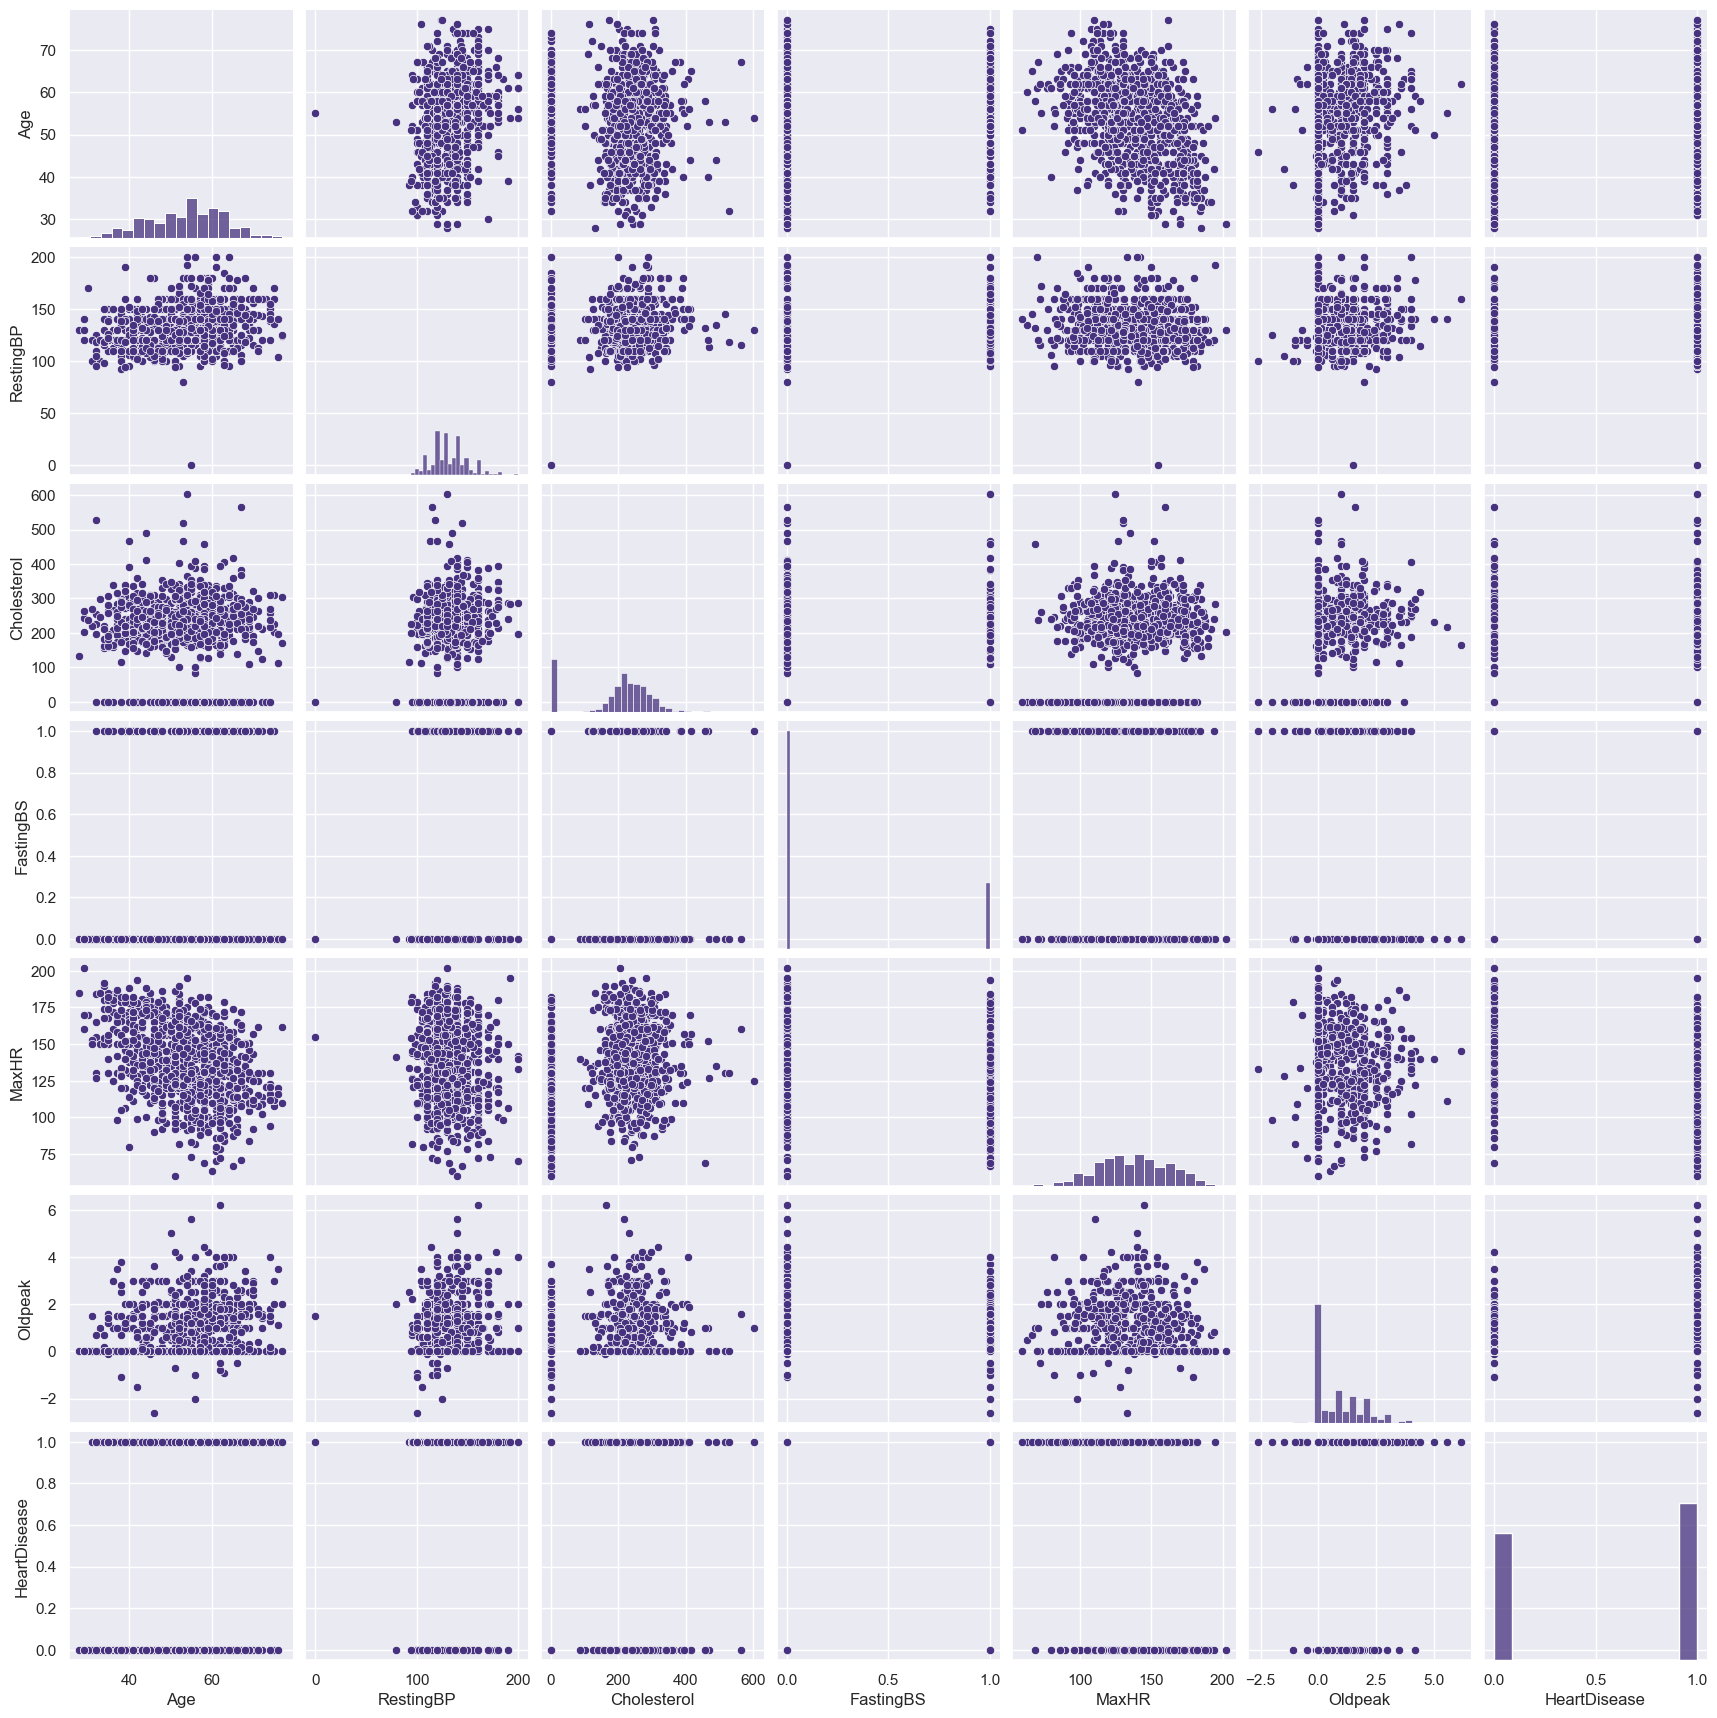

In [15]:
sns.pairplot(df)
plt.show()

In [16]:
df.groupby(['Sex','RestingECG'])['Cholesterol'].mean().sort_values(ascending=True)

Sex  RestingECG
M    ST            157.233333
     Normal        186.965438
     LVH           221.411348
F    Normal        226.305085
     ST            232.857143
     LVH           283.553191
Name: Cholesterol, dtype: float64

In [17]:
df.groupby(['ChestPainType','ST_Slope'])['MaxHR'].mean().sort_values(ascending=True)

ChestPainType  ST_Slope
ASY            Flat        123.581761
               Down        125.847826
TA             Down        127.250000
NAP            Flat        134.568182
ATA            Flat        140.031250
ASY            Up          141.189394
NAP            Down        143.100000
TA             Up          149.250000
               Flat        150.409091
NAP            Up          150.514286
ATA            Down        152.333333
               Up          152.521739
Name: MaxHR, dtype: float64

# Encoding

In [18]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [19]:
df['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [20]:
df['RestingECG'].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [21]:
df['ExerciseAngina'].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [22]:
df['ST_Slope'].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

In [23]:
# Ordinal Encoding:
df['ChestPainType']=df['ChestPainType'].map({
'TA':0,
'ATA': 1,
'NAP': 2,
'ASY': 3


})

In [24]:
df['RestingECG']=df['RestingECG'].map( {
    'Normal': 0,
    'LVH': 1,
    'ST': 2
}
)

In [25]:
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['ExerciseAngina']=le.fit_transform(df['ExerciseAngina'])
df['ST_Slope']=le.fit_transform(df['ST_Slope'])

In [26]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,0,172,0,0.0,2,0
1,49,0,2,160,180,0,0,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,3,138,214,0,0,108,1,1.5,1,1
4,54,1,2,150,195,0,0,122,0,0.0,2,0


# Defining X and y

In [27]:
X=df.drop(columns='HeartDisease')
y=df['HeartDisease']

# Train-Test Split

In [28]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

# Model Building

In [29]:
dt=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Predictiion

In [30]:
y_pred=dt.predict(x_test)
y_pred

array([0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1])

# Evaluation

In [31]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.86      0.78        98
           1       0.88      0.75      0.81       132

    accuracy                           0.80       230
   macro avg       0.80      0.80      0.79       230
weighted avg       0.81      0.80      0.80       230



In [32]:
print('Training Accuracy: ',dt.score(x_train,y_train))
print('Testing Accuracy: ',dt.score(x_test,y_test))

Training Accuracy:  1.0
Testing Accuracy:  0.7956521739130434


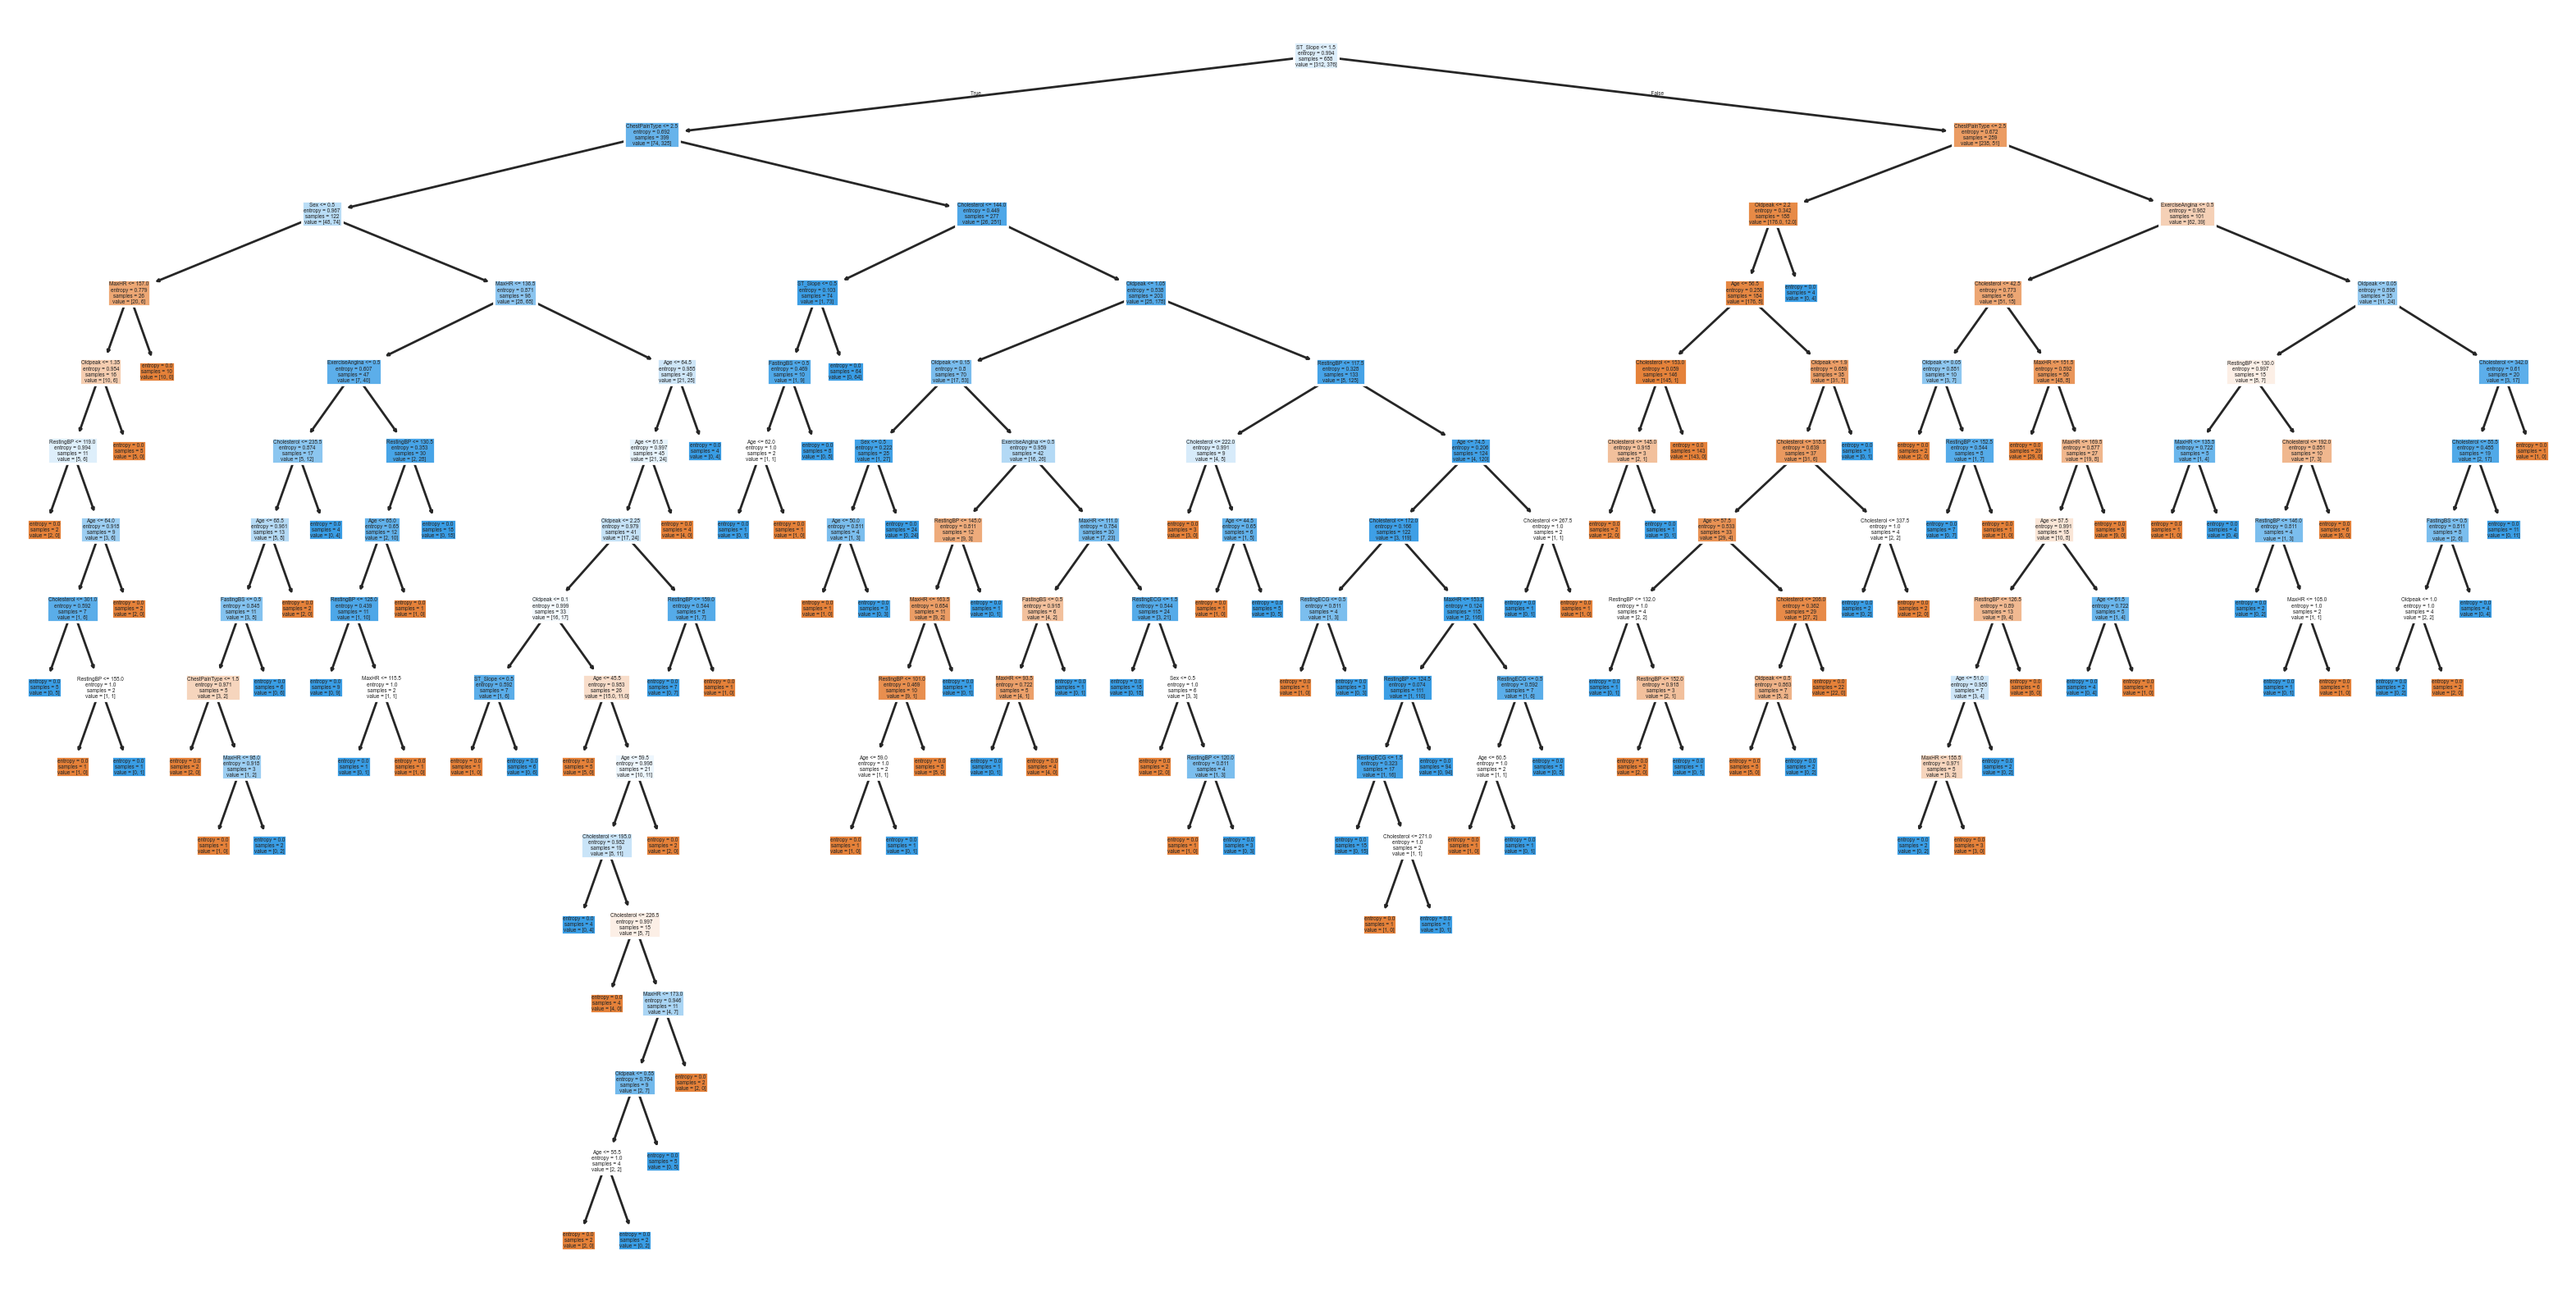

In [33]:
plt.figure(figsize=(20,10),dpi=200)
tree.plot_tree(dt,feature_names=X.columns,filled=True)
plt.show()

# Hyperparameter Tuning


# Pre Pruning


In [34]:
print(f'Number of Leaf Node: {dt.get_n_leaves()}')
print(f'Number of depth : {dt.get_depth()}')

Number of Leaf Node: 100
Number of depth : 15


In [35]:
params={
    'max_depth':[5,6,7,8],
    'min_samples_split':[3,5,7,9]
}

In [36]:
grid=GridSearchCV(DecisionTreeClassifier(criterion='entropy',random_state=42),params,verbose=1)
grid.fit(x_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [5, 6, ...], 'min_samples_split': [3, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [37]:
grid.best_params_

{'max_depth': 5, 'min_samples_split': 3}

In [38]:
dt=DecisionTreeClassifier(max_depth=5,min_samples_split=3,random_state=42)
dt.fit(x_train,y_train)
print('Training Accuracy: ',dt.score(x_train,y_train))
print('Testing Accuracy: ',dt.score(x_test,y_test))

Training Accuracy:  0.8924418604651163
Testing Accuracy:  0.8521739130434782


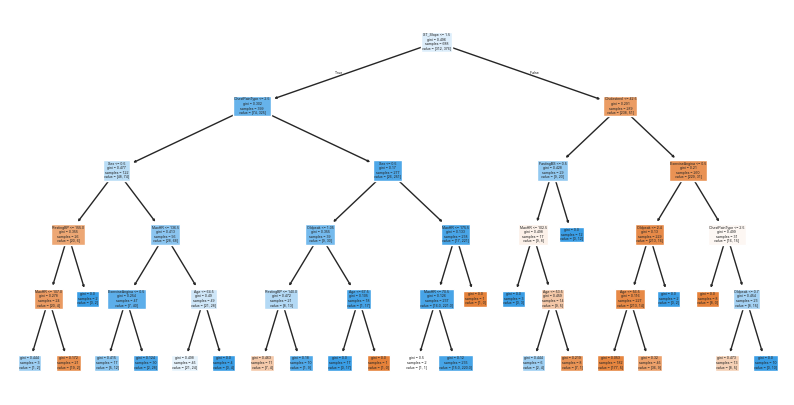

In [39]:
plt.figure(figsize=(10,5))
tree.plot_tree(dt,feature_names=X.columns,filled=True)
plt.show()

# Post Pruning

In [40]:
dt=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [41]:
alpha=dt.cost_complexity_pruning_path(X,y)['ccp_alphas']
alpha

array([0.        , 0.00176749, 0.00176749, 0.00176749, 0.00196604,
       0.00204491, 0.00212426, 0.00212426, 0.00217865, 0.00217865,
       0.00217865, 0.00217865, 0.00233302, 0.00239126, 0.0026442 ,
       0.00267516, 0.00274601, 0.00300097, 0.00300097, 0.00300097,
       0.00300097, 0.00300097, 0.00314082, 0.00331132, 0.00352899,
       0.00353498, 0.00353498, 0.00359063, 0.00360625, 0.00367506,
       0.00383009, 0.00383126, 0.00393471, 0.00397765, 0.00424851,
       0.0042738 , 0.00439182, 0.00448438, 0.00450145, 0.00466265,
       0.00468251, 0.00471932, 0.00473695, 0.00486317, 0.00489525,
       0.00493391, 0.00504627, 0.00508432, 0.00533582, 0.00603714,
       0.00616973, 0.00643923, 0.00645959, 0.00676877, 0.00686231,
       0.0071596 , 0.00769512, 0.00914669, 0.0115729 , 0.01233404,
       0.01507636, 0.01778159, 0.01797516, 0.02208059, 0.04517523,
       0.06623844, 0.29859977])

In [42]:
train_acc=[]
test_acc=[]
ccp=[]
for i in alpha:
    dt=DecisionTreeClassifier(criterion='entropy',ccp_alpha=i,random_state=42)
    dt.fit(x_train,y_train)
    train_acc.append(dt.score(x_train,y_train))
    test_acc.append(dt.score(x_test,y_test))
    ccp.append(i)

In [43]:
print(train_acc)
print(test_acc)
print(ccp)

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.998546511627907, 0.998546511627907, 0.998546511627907, 0.998546511627907, 0.9854651162790697, 0.9854651162790697, 0.9854651162790697, 0.9854651162790697, 0.9854651162790697, 0.9854651162790697, 0.9854651162790697, 0.9825581395348837, 0.9825581395348837, 0.9825581395348837, 0.9825581395348837, 0.9825581395348837, 0.9825581395348837, 0.9796511627906976, 0.9796511627906976, 0.9796511627906976, 0.9796511627906976, 0.9723837209302325, 0.9723837209302325, 0.9680232558139535, 0.9636627906976745, 0.9636627906976745, 0.9622093023255814, 0.9622093023255814, 0.9622093023255814, 0.9622093023255814, 0.9578488372093024, 0.9578488372093024, 0.9578488372093024, 0.9447674418604651, 0.9447674418604651, 0.9244186046511628, 0.8924418604651163, 0.8924418604651163, 0.8880813953488372, 0.8880813953488372, 0.8851744186046512, 0.8851744186046512, 0.8851744186046512, 0.8808139534883721, 0.877906976744186, 0.8691860465116279, 0.8691860465116279,

In [44]:
np.max(test_acc)
np.argmax(ccp)

np.int64(66)

In [45]:
ccp[66]

np.float64(0.298599769815611)

In [46]:
dt=DecisionTreeClassifier(criterion='entropy',ccp_alpha=0.298599769815611,random_state=42)
dt.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
print('Training Accuracy: ',dt.score(x_train,y_train))
print('Testing Accuracy: ',dt.score(x_test,y_test))

Training Accuracy:  0.8183139534883721
Testing Accuracy:  0.8


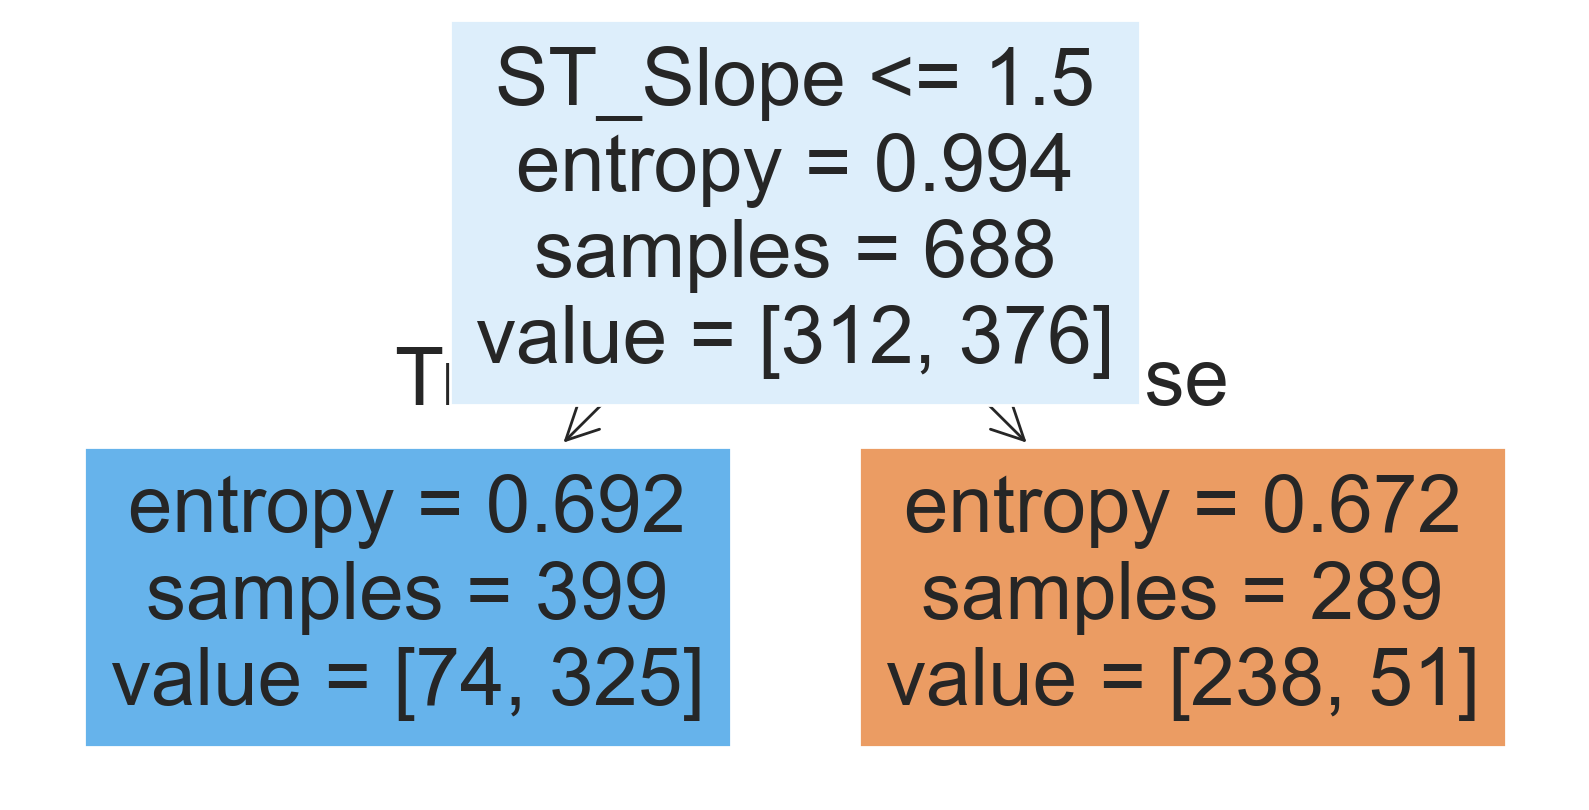

In [48]:
plt.figure(figsize=(10,5),dpi=200)
tree.plot_tree(dt,feature_names=X.columns,filled=True)
plt.show()

# Conclusion
The results indicate that the **Decision Tree model without pruning is overfitting the training data**, as it achieved **100% training accuracy** but only **79.57% testing accuracy**. This means the model learned the training data too closely and did not generalize well to unseen data.

After applying **pre-pruning**, the model achieved **89.24% training accuracy** and **85.22% testing accuracy**, which is the highest testing accuracy among all three approaches. This demonstrates that pre-pruning successfully reduced overfitting and improved the model's ability to generalize to new data.

With **post-pruning**, the training accuracy further decreased to **81.83%**, while the testing accuracy became **80.00%**. Although post-pruning reduced model complexity, it also removed some useful decision rules, leading to lower predictive performance compared to pre-pruning.

Overall, **the pre-pruned Decision Tree model is the best-performing model**, as it provides the highest testing accuracy and achieves a better balance between learning the training data and generalizing to unseen observations. Therefore, pre-pruning is the most suitable approach for this heart disease classification problem.
